# Install Dependencies

In [4]:
!pip install xgboost seaborn scikit-learn pandas numpy matplotlib

# Download and Load the Dataset

In [5]:
import pandas as pd
import urllib.request
import zipfile
from pathlib import Path

# Create a data folder
data_path = Path("data")
data_path.mkdir(exist_ok=True)

zip_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
zip_file = data_path / "bank-additional.zip"
csv_file = data_path / "bank-additional-full.csv"

# Download if not present
if not csv_file.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(zip_url, zip_file)

    # Extract CSV
    with zipfile.ZipFile(zip_file, 'r') as z:
        for name in z.namelist():
            if name.endswith("bank-additional-full.csv"):
                z.extract(name, data_path)
                (data_path / name).rename(csv_file)
                break

print("Dataset ready.")

# Load CSV (semicolon separated)
df = pd.read_csv(csv_file, sep=';')
df.head()

Dataset ready.


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Basic EDA & Target Encoding

In [6]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget counts:", df['y'].value_counts())

# Encode target
df['y'] = df['y'].map({'no': 0, 'yes': 1})
df['y'].value_counts()

Shape: (41188, 21)

Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target counts: y
no     36548
yes     4640
Name: count, dtype: int64


,count
y,
0,36548
1,4640


# Preprocessing & Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Drop leakage column
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])

X = df.drop(columns=['y'])
y = df['y']

cat_cols = [c for c in X.columns if X[c].dtype == 'object']
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Pipelines
preprocess_default = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

# Special NB pipeline (non-negative)
from sklearn.base import BaseEstimator, TransformerMixin

class MinShift(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = np.asarray(X, float)
        self.min_ = np.nanmin(X, axis=0)
        return self
    def transform(self, X):
        X = np.asarray(X, float)
        shift = np.where(self.min_<0, -self.min_, 0)
        return X + shift

preprocess_nb = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ("num", Pipeline([("shift", MinShift())]), num_cols),
    ]
)


Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


# Train All Six Models

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocess_default),
        ("clf", LogisticRegression(max_iter=300, class_weight="balanced"))
    ]),

    "Decision Tree": Pipeline([
        ("prep", preprocess_default),
        ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=42))
    ]),

    "KNN": Pipeline([
        ("prep", preprocess_default),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Naive Bayes": Pipeline([
        ("prep", preprocess_nb),
        ("clf", MultinomialNB())
    ]),


"Random Forest": Pipeline([
    ("prep", preprocess_default),
    ("clf", RandomForestClassifier(
        n_estimators=100,        # fewer trees than before (biggest impact on size)
        max_depth=12,            # cap depth to control size
        max_leaf_nodes=512,      # additional cap on tree size
        min_samples_split=10,    # light regularization
        min_samples_leaf=5,      # light regularization
        ccp_alpha=0.0005,        # post-pruning (keeps trees smaller)
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
]),


    "XGBoost": Pipeline([
        ("prep", preprocess_default),
        ("clf", XGBClassifier(
            n_estimators=300, learning_rate=0.1, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', random_state=42
        ))
    ])
}

models

{'Logistic Regression': Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['job', 'marital',
                                                    'education', 'default',
                                                    'housing', 'loan', 'contact',
                                                    'month', 'day_of_week',
                                                    'poutcome']),
                                                  ('num', StandardScaler(),
                                                   ['age', 'campaign', 'pdays',
                                                    'previous', 'emp.var.rate',
                                                    'cons.price.idx',
                                                    'cons.conf.idx', 'euribor3m',
                                            

# Evaluate Models (Accuracy, AUC, Precision, Recall, F1, MCC)

In [43]:
# === Evaluate & SAVE everything ===
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix, classification_report
)
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from pathlib import Path
import joblib, re, os, datetime

# Create output folders
REPORTS_DIR = Path("reports"); REPORTS_DIR.mkdir(exist_ok=True)
MODELS_DIR  = Path("model");   MODELS_DIR.mkdir(exist_ok=True)

def safe_name(name: str) -> str:
    """Make a file-system friendly name."""
    n = name.lower().strip()
    n = re.sub(r"\\s+", "_", n)         # spaces -> underscores
    n = re.sub(r"[^a-z0-9_\\-]+", "", n) # drop weird chars
    return n

results = []

for name, pipe in models.items():
    tag = safe_name(name)
    print(f"\n==== Training {name} ====")
    pipe.fit(X_train, y_train)

    # Predictions
    y_pred  = pipe.predict(X_test)
    # Probability or decision scores for AUC
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    elif hasattr(pipe, "decision_function"):
        dec = pipe.decision_function(X_test)
        y_proba = 1 / (1 + np.exp(-dec))  # logistic transform
    else:
        # Fallback: use labels; ROC-AUC will be less informative but valid for binary
        y_proba = y_pred.astype(float)

    # Metrics
    row = {
        "ML Model Name": name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "AUC":       roc_auc_score(y_test, y_proba),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "MCC":       matthews_corrcoef(y_test, y_pred),
    }
    results.append(row)

    # === SAVE 1: pickled model (entire pipeline) ===
    model_path = MODELS_DIR / f"{tag}.pkl"
    joblib.dump(pipe, model_path, compress=("xz", 6))

    # === SAVE 2: confusion matrix image ===
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4.5, 3.6), dpi=140)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    fig_path = REPORTS_DIR / f"{tag}_confusion_matrix.png"
    plt.savefig(fig_path)
    plt.close()

    # === SAVE 3: classification report (.txt) ===
    report_txt = classification_report(y_test, y_pred, target_names=["no","yes"])
    with open(REPORTS_DIR / f"{tag}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(f"{name} — Classification Report\n")
        f.write(f"Generated: {datetime.datetime.now():%Y-%m-%d %H:%M:%S}\n\n")
        f.write(report_txt)

# === SAVE 4: metrics summary (CSV) ===
summary_df = pd.DataFrame(results)[["ML Model Name","Accuracy","AUC","Precision","Recall","F1","MCC"]]
summary_df.sort_values(by=["F1", "AUC"], ascending=False, inplace=True)
summary_df.to_csv("metrics_summary.csv", index=False)

# Show the in-notebook table too
summary_df


==== Training Logistic Regression ====

==== Training Decision Tree ====

==== Training KNN ====

==== Training Naive Bayes ====

==== Training Random Forest ====

==== Training XGBoost ====


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
4,Random Forest,0.853120,0.809427,0.404212,0.641164,0.495833,0.430140
0,Logistic Regression,0.835033,0.800941,0.367872,0.646552,0.468933,0.401084
5,XGBoost,0.901918,0.803468,0.638889,0.297414,0.405882,0.391562
2,KNN,0.897184,0.744019,0.583851,0.303879,0.399717,0.371945
1,Decision Tree,0.847050,0.622237,0.324524,0.330819,0.327641,0.241375
3,Naive Bayes,0.897669,0.680158,0.647059,0.201509,0.307313,0.322297


# Confusion Matrices & Classification Reports


===  Logistic Regression ===


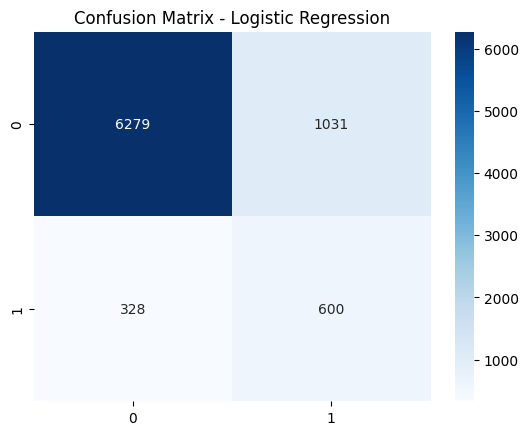

              precision    recall  f1-score   support

          no       0.95      0.86      0.90      7310
         yes       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238


===  Decision Tree ===


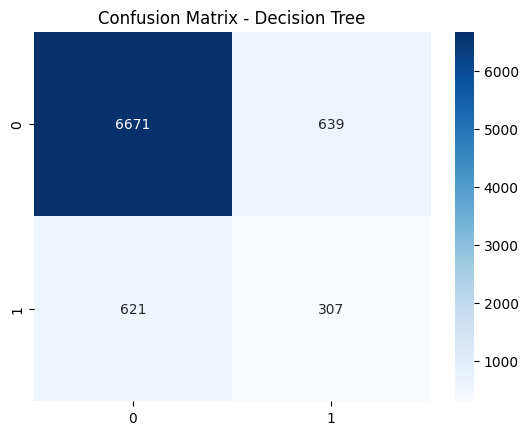

              precision    recall  f1-score   support

          no       0.91      0.91      0.91      7310
         yes       0.32      0.33      0.33       928

    accuracy                           0.85      8238
   macro avg       0.62      0.62      0.62      8238
weighted avg       0.85      0.85      0.85      8238


===  KNN ===


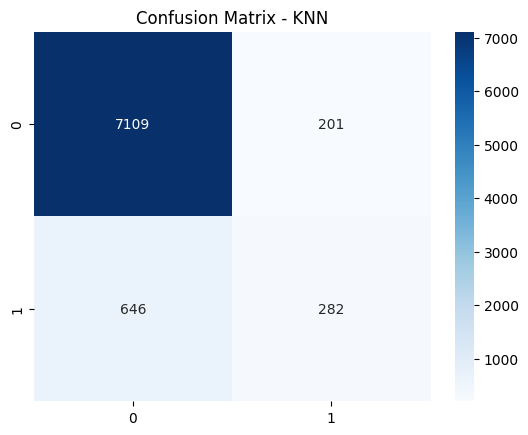

              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7310
         yes       0.58      0.30      0.40       928

    accuracy                           0.90      8238
   macro avg       0.75      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238


===  Naive Bayes ===


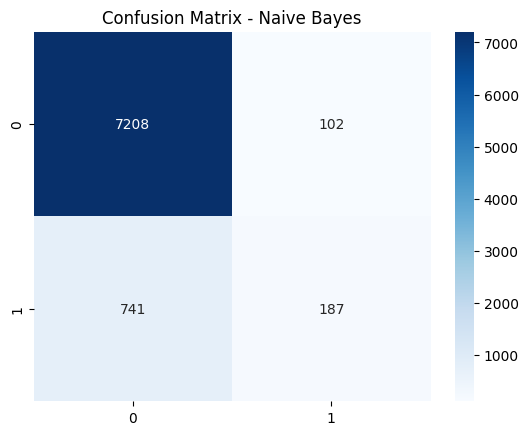

              precision    recall  f1-score   support

          no       0.91      0.99      0.94      7310
         yes       0.65      0.20      0.31       928

    accuracy                           0.90      8238
   macro avg       0.78      0.59      0.63      8238
weighted avg       0.88      0.90      0.87      8238


===  Random Forest ===


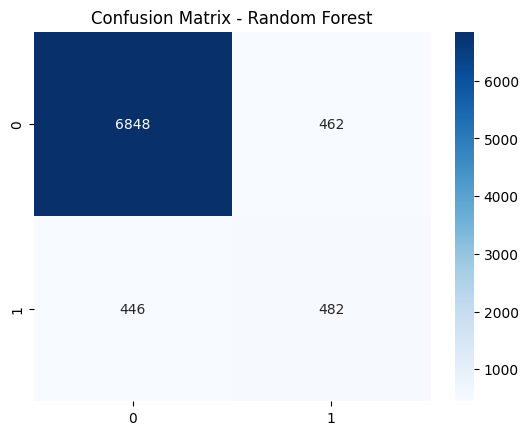

              precision    recall  f1-score   support

          no       0.94      0.94      0.94      7310
         yes       0.51      0.52      0.51       928

    accuracy                           0.89      8238
   macro avg       0.72      0.73      0.73      8238
weighted avg       0.89      0.89      0.89      8238


===  XGBoost ===


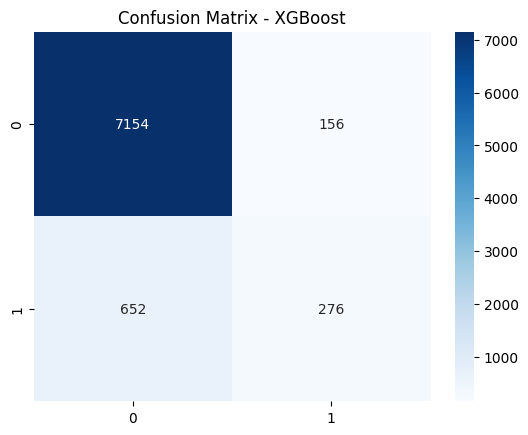

              precision    recall  f1-score   support

          no       0.92      0.98      0.95      7310
         yes       0.64      0.30      0.41       928

    accuracy                           0.90      8238
   macro avg       0.78      0.64      0.68      8238
weighted avg       0.89      0.90      0.89      8238



In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    print("\n=== ", name, "===")
    pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    print(classification_report(y_test, pred, target_names=["no","yes"]))

# Generate metrics_summary.md

In [46]:
# Create a Markdown table version for README
import pandas as pd

summary_df = pd.read_csv("metrics_summary.csv")
lines = [
    "| ML Model Name | Accuracy | AUC | Precision | Recall | F1 | MCC |\n",
    "|---|---:|---:|---:|---:|---:|---:|\n",
]
for _, r in summary_df.iterrows():
    lines.append(
        f"| {r['ML Model Name']} | {r['Accuracy']:.4f} | {r['AUC']:.4f} | "
        f"{r['Precision']:.4f} | {r['Recall']:.4f} | {r['F1']:.4f} | {r['MCC']:.4f} |\n"
    )

with open("metrics_summary.md", "w", encoding="utf-8") as f:
    f.writelines(lines)

print("Wrote metrics_summary.md")
print("\nPreview:\n")
print("".join(lines))

Wrote metrics_summary.md

Preview:

| ML Model Name | Accuracy | AUC | Precision | Recall | F1 | MCC |
|---|---:|---:|---:|---:|---:|---:|
| Random Forest | 0.8531 | 0.8094 | 0.4042 | 0.6412 | 0.4958 | 0.4301 |
| Logistic Regression | 0.8350 | 0.8009 | 0.3679 | 0.6466 | 0.4689 | 0.4011 |
| XGBoost | 0.9019 | 0.8035 | 0.6389 | 0.2974 | 0.4059 | 0.3916 |
| KNN | 0.8972 | 0.7440 | 0.5839 | 0.3039 | 0.3997 | 0.3719 |
| Decision Tree | 0.8471 | 0.6222 | 0.3245 | 0.3308 | 0.3276 | 0.2414 |
| Naive Bayes | 0.8977 | 0.6802 | 0.6471 | 0.2015 | 0.3073 | 0.3223 |



# Quick sanity check of saved files

In [47]:
import os, glob, pandas as pd

print("CSV & MD:")
print(glob.glob("metrics_summary.*"))

print("\nPickled models in model/:")
print(glob.glob("model/*.pkl"))

print("\nReports (images + txt) in reports/:")
print(sorted(glob.glob("reports/*")))

CSV & MD:
['metrics_summary.md', 'metrics_summary.csv']

Pickled models in model/:
['model/knn.pkl', 'model/logisticregression.pkl', 'model/randomforest.pkl', 'model/xgboost.pkl', 'model/decisiontree.pkl', 'model/naivebayes.pkl']

Reports (images + txt) in reports/:
['reports/decisiontree_classification_report.txt', 'reports/decisiontree_confusion_matrix.png', 'reports/knn_classification_report.txt', 'reports/knn_confusion_matrix.png', 'reports/logisticregression_classification_report.txt', 'reports/logisticregression_confusion_matrix.png', 'reports/naivebayes_classification_report.txt', 'reports/naivebayes_confusion_matrix.png', 'reports/randomforest_classification_report.txt', 'reports/randomforest_confusion_matrix.png', 'reports/xgboost_classification_report.txt', 'reports/xgboost_confusion_matrix.png']


# Create requirements.txt and README.md

In [51]:
from pathlib import Path

# --- Minimal requirements.txt ---
requirements_txt = """\
streamlit>=1.29
scikit-learn>=1.2
xgboost>=1.7
pandas>=1.5
numpy>=1.23
matplotlib>=3.7
seaborn>=0.12
joblib>=1.3
"""
Path("requirements.txt").write_text(requirements_txt, encoding="utf-8")

# --- Readme.md-------
readme_md = """\
# Assignment Name
Machine Learning Assignment - 2

## Problem Statement
Build and compare multiple ML classifiers on the UCI Bank Marketing dataset to predict whether a client will subscribe to a term deposit.

## Dataset Description
- Source: UCI Bank Marketing (file: bank-additional-full.csv inside bank-additional.zip)
- Rows: ~41,188
- Features: 20 (mix of categorical & numeric)
- Target: y (0 = no, 1 = yes)
- Note: The column `duration` is excluded during modeling to avoid leakage.

## Models Used
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbors (KNN)
4. Naive Bayes (Multinomial)
5. Random Forest (Ensemble)
6. XGBoost (Ensemble)

## Model Comparison Table

|ML Model Name|Accuracy|AUC|Precision|Recall|F1|MCC|
|---|---|---|---|---|---|---|
|Random Forest|0\.8531196892449624|0\.8094274051842069|0\.40421195652173914|0\.6411637931034483|0\.49583333333333335|0\.4301399793328449|
|Logistic Regression|0\.8350327749453751|0\.80094145065805|0\.3678724708767627|0\.646551724137931|0\.46893317702227433|0\.40108374113193157|
|XGBoost|0\.9019179412478757|0\.8034678080333978|0\.6388888888888888|0\.2974137931034483|0\.40588235294117647|0\.3915621658427986|
|KNN|0\.8971837824714737|0\.7440191754328035|0\.5838509316770186|0\.30387931034482757|0\.3997165131112686|0\.37194533230817917|
|Decision Tree|0\.8470502549162418|0\.6222374876173404|0\.32452431289640593|0\.3308189655172414|0\.327641408751334|0\.24137501776047923|
|Naive Bayes|0\.8976693372177713|0\.6801583358884854|0\.6470588235294118|0\.20150862068965517|0\.3073130649137223|0\.3222971458261065|


## Model Observation Table

| ML Model Name             | Observation about model performance |
|---------------------------|-------------------------------------|
| Logistic Regression       | Good linear baseline; stable AUC and precision/recall with class weighting; may underfit complex patterns. |
| Decision Tree             | Interpretable but higher variance; without pruning can overfit; generally lower AUC/F1 than ensembles. |
| KNN                       | Sensitive to scaling and high‑dimensional one‑hot space; moderate metrics; inference is costlier. |
| Naive Bayes (Multinomial) | Very fast and OHE‑friendly; reasonable recall but typically lower precision/AUC vs linear/ensemble models. |
| Random Forest (Ensemble)  | Robust, captures interactions; usually strong F1/AUC out‑of‑the‑box; useful feature importance. |
| XGBoost (Ensemble)        | Often best F1/AUC; models subtle interactions; benefits from tuning; strong precision–recall balance. |
"""



Path("README.md").write_text(readme_md, encoding="utf-8")

print("✅ Created/updated requirements.txt and README.md")
print("Wrote metrics_summary.md")
print("\nPreview:\n")
print("".join(lines))

✅ Created/updated requirements.txt and README.md
Wrote metrics_summary.md

Preview:

| ML Model Name | Accuracy | AUC | Precision | Recall | F1 | MCC |
|---|---:|---:|---:|---:|---:|---:|
| Random Forest | 0.8531 | 0.8094 | 0.4042 | 0.6412 | 0.4958 | 0.4301 |
| Logistic Regression | 0.8350 | 0.8009 | 0.3679 | 0.6466 | 0.4689 | 0.4011 |
| XGBoost | 0.9019 | 0.8035 | 0.6389 | 0.2974 | 0.4059 | 0.3916 |
| KNN | 0.8972 | 0.7440 | 0.5839 | 0.3039 | 0.3997 | 0.3719 |
| Decision Tree | 0.8471 | 0.6222 | 0.3245 | 0.3308 | 0.3276 | 0.2414 |
| Naive Bayes | 0.8977 | 0.6802 | 0.6471 | 0.2015 | 0.3073 | 0.3223 |



In [50]:
# Zip the 'reports' folder and download once
import os, shutil
from pathlib import Path
from google.colab import files

reports_dir = Path("reports")
assert reports_dir.exists() and reports_dir.is_dir(), "reports/ folder not found. Run your training/evaluation first."

# Create a fresh zip
zip_base = "reports"
zip_path = shutil.make_archive(zip_base, "zip", root_dir=str(reports_dir))
print("Created archive:", zip_path)

# Show what's inside (for sanity check)
print("\nFiles in reports/:")
for p in sorted(reports_dir.glob("*")):
    print(" -", p.name)

# Download the zip
files.download(zip_path)

Created archive: /content/reports.zip

Files in reports/:
 - decisiontree_classification_report.txt
 - decisiontree_confusion_matrix.png
 - knn_classification_report.txt
 - knn_confusion_matrix.png
 - logisticregression_classification_report.txt
 - logisticregression_confusion_matrix.png
 - naivebayes_classification_report.txt
 - naivebayes_confusion_matrix.png
 - randomforest_classification_report.txt
 - randomforest_confusion_matrix.png
 - xgboost_classification_report.txt
 - xgboost_confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
# Zip the 'model' folder and download it
import shutil
from pathlib import Path
from google.colab import files

model_dir = Path("model")
assert model_dir.exists() and model_dir.is_dir(), "model/ folder not found. Run your training notebook first to generate artifacts."

# Make sure key files exist (optional safety check)
expected = [
    "Bank_Marketing_Models.ipynb",
    "logistic_regression.pkl",
    "decision_tree.pkl",
    "knn.pkl",
    "naive_bayes.pkl",
    "random_forest.pkl",
    "xgboost.pkl",
]
missing = [f for f in expected if not (model_dir / f).exists()]
if missing:
    print("Warning: these expected files are missing in model/:", missing)

zip_base = "model"
zip_path = shutil.make_archive(zip_base, "zip", root_dir=str(model_dir))
print("Created archive:", zip_path)

# Download the zip
files.download(zip_path)

Created archive: /content/model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
# === Create Streamlit app.py ===
from pathlib import Path
from textwrap import dedent

app_code = dedent("""
    import streamlit as st
    import pandas as pd
    import numpy as np
    import joblib
    import os
    from sklearn.metrics import (
        accuracy_score, roc_auc_score, precision_score,
        recall_score, f1_score, matthews_corrcoef,
        confusion_matrix, classification_report
    )
    import seaborn as sns
    import matplotlib.pyplot as plt

    st.set_page_config(page_title="Bank Marketing — ML Models", layout="wide")

    st.title("📊 Bank Marketing — Model Inference & Evaluation")
    st.write(
        "Upload **test data** (CSV) and choose a trained model. "
        "If your CSV includes a **`y`** column (0/1 or 'no'/'yes'), the app will compute evaluation metrics."
    )

    # === IMPORTANT: Required input columns (duration and y are excluded) ===
    REQUIRED_COLUMNS = [
        "age","job","marital","education","default","housing","loan",
        "contact","month","day_of_week","campaign","pdays","previous",
        "poutcome","emp.var.rate","cons.price.idx","cons.conf.idx",
        "euribor3m","nr.employed"
    ]

    # Small CSV template for users to download
    def get_template_df():
        # One empty row with headers only
        return pd.DataFrame(columns=REQUIRED_COLUMNS)

    with st.expander("📥 Download CSV template (headers only)"):
        tmpl_csv = get_template_df().to_csv(index=False)
        st.download_button(
            label="Download template.csv",
            data=tmpl_csv,
            file_name="template_bank_marketing.csv",
            mime="text/csv"
        )
        st.caption("The uploaded CSV must have **exactly these headers** (order doesn’t matter).")

    # === File uploader ===
    uploaded = st.file_uploader(
        "Upload CSV (test split only). Columns must match the template headers.",
        type=["csv"]
    )

    # === Model selector (maps to pickles under model/) ===
    MODEL_FILES = {
        "Logistic Regression":       "logistic_regression.pkl",
        "Decision Tree":             "decision_tree.pkl",
        "KNN":                       "knn.pkl",
        "Naive Bayes":               "naive_bayes.pkl",
        "Random Forest":             "random_forest.pkl",
        "XGBoost":                   "xgboost.pkl",
    }

    model_name = st.selectbox("Choose a model", list(MODEL_FILES.keys()))
    run_btn = st.button("Run")

    def normalize_target(y_series):
        # Accept 0/1 or 'no'/'yes' (case-insensitive)
        mapping = {"no": 0, "yes": 1, "0": 0, "1": 1}
        def _map_one(v):
            if pd.isna(v):
                return np.nan
            s = str(v).strip().lower()
            if s in mapping:
                return mapping[s]
            try:
                return int(float(s))
            except Exception:
                return np.nan
        return y_series.map(_map_one).astype("float")

    def align_columns(df):
        # Keep only required; add any missing as NaN (pipeline will handle via OHE/transform)
        cols = df.columns.tolist()
        to_keep = [c for c in cols if c in REQUIRED_COLUMNS]
        out = df[to_keep].copy()
        for c in REQUIRED_COLUMNS:
            if c not in out.columns:
                out[c] = np.nan
        # Reorder to a stable order (not strictly required, but nice)
        out = out[REQUIRED_COLUMNS]
        return out

    def load_model(pkl_name):
        p = Path("model") / pkl_name
        if not p.exists():
            st.error(f"Model file not found: {p}")
            return None
        try:
            return joblib.load(p)
        except Exception as e:
            st.error(f"Failed to load model: {e}")
            return None

    if run_btn:
        if uploaded is None:
            st.warning("Please upload a CSV first.")
            st.stop()

        # Read CSV
        try:
            raw_df = pd.read_csv(uploaded)
        except Exception as e:
            st.error(f"Could not read CSV: {e}")
            st.stop()

        # Separate target if present
        y_true = None
        y_col_present = "y" in raw_df.columns
        if y_col_present:
            y_true = normalize_target(raw_df["y"])
            raw_df = raw_df.drop(columns=["y"])

        # Align columns to what the pipeline expects (minus y and duration)
        X = align_columns(raw_df)

        # Load model
        pipe = load_model(MODEL_FILES[model_name])
        if pipe is None:
            st.stop()

        # Predict
        try:
            y_pred = pipe.predict(X)
        except Exception as e:
            st.error(f"Prediction failed: {e}")
            st.stop()

        # Try probabilities for AUC if available
        if hasattr(pipe, "predict_proba"):
            try:
                y_proba = pipe.predict_proba(X)[:, 1]
            except Exception:
                y_proba = None
        else:
            y_proba = None

        st.subheader("🔎 Results")
        st.write(f"**Rows predicted:** {len(X)}")

        # If true target present, compute metrics
        if y_col_present:
            if y_true.isna().any():
                st.warning("Some values in the `y` column could not be interpreted as 0/1 or no/yes. They were treated as NaN and dropped for scoring.")
            # Drop rows where y is NaN to compute fair scores
            mask = ~y_true.isna()
            if mask.sum() == 0:
                st.error("No valid ground-truth labels found after cleaning `y`. Cannot compute metrics.")
            else:
                yt = y_true[mask].astype(int).values
                yp = np.asarray(y_pred)[mask]
                if y_proba is not None:
                    ypb = np.asarray(y_proba)[mask]
                else:
                    ypb = None

                # Metrics
                acc = accuracy_score(yt, yp)
                prec = precision_score(yt, yp, zero_division=0)
                rec = recall_score(yt, yp, zero_division=0)
                f1 = f1_score(yt, yp, zero_division=0)
                mcc = matthews_corrcoef(yt, yp)
                auc = roc_auc_score(yt, ypb) if ypb is not None else float("nan")

                # Show metrics nicely
                c1, c2, c3, c4, c5, c6 = st.columns(6)
                c1.metric("Accuracy", f"{acc:.4f}")
                c2.metric("AUC", f"{auc:.4f}" if not np.isnan(auc) else "N/A")
                c3.metric("Precision", f"{prec:.4f}")
                c4.metric("Recall", f"{rec:.4f}")
                c5.metric("F1", f"{f1:.4f}")
                c6.metric("MCC", f"{mcc:.4f}")

                # Confusion matrix
                st.markdown("#### Confusion Matrix")
                cm = confusion_matrix(yt, yp)
                fig, ax = plt.subplots(figsize=(4, 3))
                sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
                ax.set_xlabel("Predicted")
                ax.set_ylabel("Actual")
                st.pyplot(fig)

                # Classification report
                st.markdown("#### Classification Report")
                st.code(classification_report(yt, yp, target_names=["no", "yes"]))
        else:
            st.info("No `y` column found in the uploaded CSV. Displaying predictions only.")
            # Show head of predictions and (if available) probabilities
            out = pd.DataFrame({"prediction": y_pred})
            if y_proba is not None:
                out["prob_yes"] = y_proba
            st.dataframe(out.head(20))
            st.download_button(
                "Download predictions (CSV)",
                out.to_csv(index=False),
                file_name="predictions.csv",
                mime="text/csv"
            )

    st.caption("Note: Pipelines were trained with the `duration` column removed and expect the headers shown in the template.")
""")

Path("app.py").write_text(app_code, encoding="utf-8")
print("✅ Created app.py in the current directory")

✅ Created app.py in the current directory
